                 ID  transectStart_X  transectStart_Y  transectEnd_X  \
0  usa_TX_0001_0001       -93.838730        29.679420     -93.838165   
1  usa_TX_0001_0002       -93.839165        29.679419     -93.838630   
2  usa_TX_0001_0003       -93.839580        29.679197     -93.839134   
3  usa_TX_0001_0004       -93.840030        29.679037     -93.839660   
4  usa_TX_0001_0005       -93.840515        29.679100     -93.840210   

   transectEnd_Y    lon_mid    lat_mid        x_proj        y_proj       ds_m  \
0      29.676622 -93.838448  29.678021  2.095078e+06  7.300796e+06        NaN   
1      29.676554 -93.838898  29.677986  2.095035e+06  7.300789e+06  43.651474   
2      29.676485 -93.839357  29.677841  2.094991e+06  7.300771e+06  47.249041   
3      29.676426 -93.839845  29.677732  2.094945e+06  7.300756e+06  48.697353   
4      29.676373 -93.840362  29.677737  2.094895e+06  7.300754e+06  50.008749   

   ...         SCE         NSM       EPR       LRR  rate_ols  intercept_ols  \
0

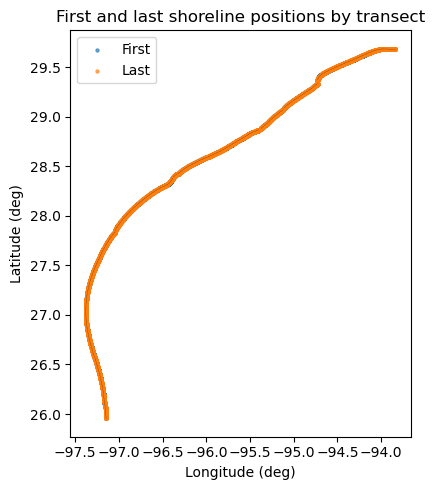

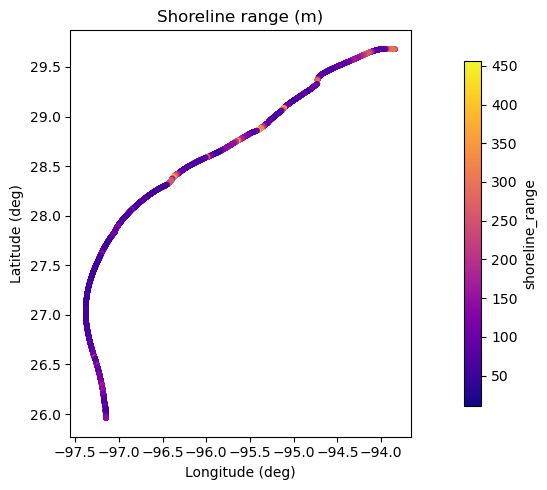

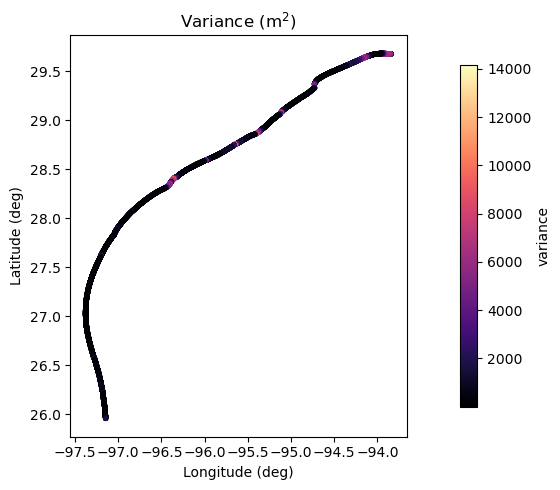

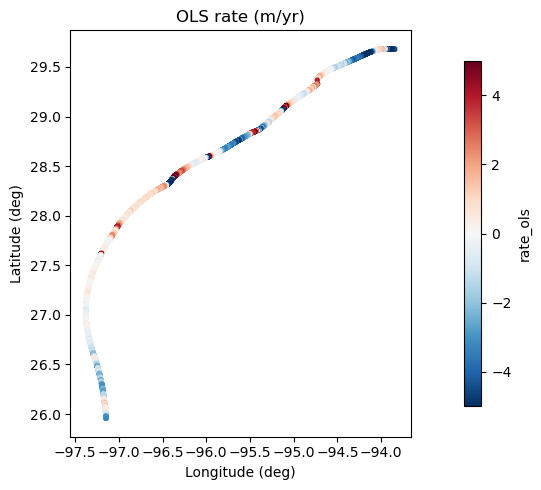

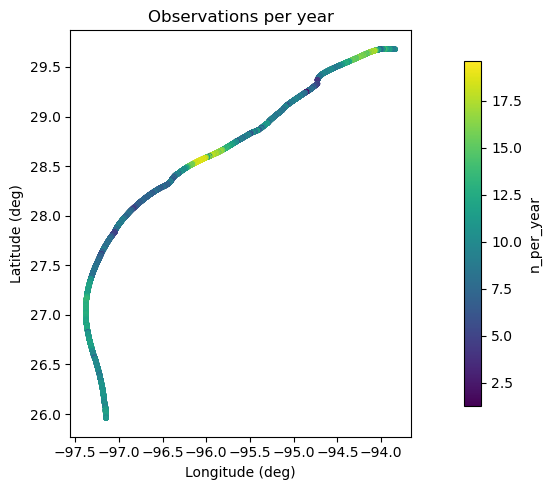

In [1]:
"""
shoreline_stats

Utilities for analyzing CoastSat/DSAS-style satellite-derived shoreline CSV files.

Primary workflow
----------------
1. Read and prepare shoreline observations from CSV
2. Build a transect geometry table
3. Add along-coast distance (south -> northeast, usually by ID order)
4. Compute:
   - basic per-transect statistics
   - OLS fit statistics
   - optional Theil-Sen fit statistics
   - DSAS-style metrics
5. Merge everything into one dataframe
6. Make simple maps and along-coast plots

Notes
-----
- Cross-shore shoreline position is taken from the 'distance' column (meters).
- Landward/seaward should be defined from 'distance', not lon/lat:
    landward = min(distance)
    seaward  = max(distance)
- For this dataset, simple metric analyses should use 'distance' directly.
- Geographic lon/lat are used for plotting and for constructing along-coast distance.
- For Texas, a single projected CRS like EPSG:3083 is convenient for along-coast distance.

Dependencies
------------
Required:
    numpy, pandas, matplotlib
Optional:
    geopandas      (for projected along-coast distance)
    scikit-learn   (for OLS and sklearn Theil-Sen)

Author
------
Packaged for the Texas shoreline workflow
"""

from __future__ import annotations

import re
from dataclasses import dataclass
from typing import Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

import geopandas as gpd
from sklearn.linear_model import LinearRegression, TheilSenRegressor
from scipy.stats import theilslopes as scipy_theilslopes

from shapely.geometry import LineString, Point, MultiPoint, GeometryCollection
from pyproj import Transformer

# -----------------------------------------------------------------------------
# Configuration / helpers
# -----------------------------------------------------------------------------

@dataclass
class AnalysisConfig:
    """Configuration for shoreline analysis."""

    datetime_col: str = "datetime"
    id_col: str = "ID"
    distance_col: str = "distance"
    lon_col: str = "shoreline_x"
    lat_col: str = "shoreline_y"
    start_x_col: str = "transectStart_X"
    start_y_col: str = "transectStart_Y"
    end_x_col: str = "transectEnd_X"
    end_y_col: str = "transectEnd_Y"
    proj_crs: str = "EPSG:3083"  # Texas Centric Albers Equal Area
    source_crs: str = "EPSG:4326"


def _require_package(obj, package_name: str, feature: str) -> None:
    if obj is None:
        raise ImportError(
            f"{feature} requires '{package_name}', but it is not installed."
        )


def _decimal_year(dt: pd.Series) -> pd.Series:
    """Convert datetime series to decimal year."""
    year = dt.dt.year
    doy = dt.dt.dayofyear
    return year + (doy - 1) / 365.25


def _transect_numeric_id(id_value: str) -> Tuple[int, int]:
    """
    Parse IDs like 'usa_TX_0001_0001' into sortable integers.

    Returns
    -------
    tuple of ints
        Usually (first transect integer, second transect integer)
    """
    m = re.search(r"_(\d{4})_(\d{4})$", str(id_value))
    if m:
        return int(m.group(1)), int(m.group(2))
    return (10**9, 10**9)


def _geographic_aspect(lat_deg: Sequence[float]) -> float:
    """Approximate aspect ratio for lon/lat plotting."""
    mean_lat = np.nanmean(np.asarray(lat_deg))
    return 1.0 / np.cos(np.deg2rad(mean_lat))


def _ols_fit(t: np.ndarray, x: np.ndarray):
    """
    Fast OLS slope/intercept/r2/rmse without scikit-learn.

    Parameters
    ----------
    t : (n,) array
        Decimal years.
    x : (n,) array
        Shoreline distance (m).
    """
    mask = np.isfinite(t) & np.isfinite(x)
    t = np.asarray(t)[mask]
    x = np.asarray(x)[mask]

    if t.size < 3:
        return np.nan, np.nan, np.nan, np.nan

    p = np.polyfit(t, x, 1)
    slope, intercept = float(p[0]), float(p[1])
    xhat = slope * t + intercept
    ss_res = float(np.sum((x - xhat) ** 2))
    ss_tot = float(np.sum((x - np.mean(x)) ** 2))
    r2 = np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot
    rmse = float(np.sqrt(np.mean((x - xhat) ** 2)))
    return slope, intercept, r2, rmse


def _theil_sen_pairwise(t: np.ndarray, x: np.ndarray):
    """
    Fast exact Theil-Sen slope/intercept using pairwise slopes.

    This avoids sklearn overhead and is often much faster for modest n.
    """
    mask = np.isfinite(t) & np.isfinite(x)
    t = np.asarray(t)[mask]
    x = np.asarray(x)[mask]

    n = t.size
    if n < 5:
        return np.nan, np.nan

    dt = t[np.newaxis, :] - t[:, np.newaxis]
    dx = x[np.newaxis, :] - x[:, np.newaxis]
    iu = np.triu_indices(n, k=1)
    valid = dt[iu] != 0
    slopes = dx[iu][valid] / dt[iu][valid]

    if slopes.size == 0:
        return np.nan, np.nan

    slope = float(np.median(slopes))
    intercept = float(np.median(x - slope * t))
    return slope, intercept


# -----------------------------------------------------------------------------
# Reading / preparation
# -----------------------------------------------------------------------------

def read_shoreline_csv(
    filename: str,
    config: AnalysisConfig = AnalysisConfig(),
    low_memory: bool = False,
) -> pd.DataFrame:
    """Read shoreline CSV and return a prepared dataframe."""
    df = pd.read_csv(filename, low_memory=low_memory)
    return prepare_shoreline_df(df, config=config)


def prepare_shoreline_df(
    df: pd.DataFrame,
    config: AnalysisConfig = AnalysisConfig(),
) -> pd.DataFrame:
    """
    Prepare shoreline dataframe:
    - combine date/time
    - drop rows missing core values
    - sort by ID and datetime
    - add year and decimal time t
    """
    out = df.copy()

    out[config.datetime_col] = pd.to_datetime(
        out["date"].astype(str) + " " + out["time"].astype(str),
        errors="coerce",
    )

    required = [
        config.datetime_col,
        config.id_col,
        config.distance_col,
        config.lon_col,
        config.lat_col,
        config.start_x_col,
        config.start_y_col,
        config.end_x_col,
        config.end_y_col,
    ]
    out = out.dropna(subset=required)

    out["year"] = out[config.datetime_col].dt.year
    out["t"] = _decimal_year(out[config.datetime_col])

    out = out.sort_values([config.id_col, config.datetime_col]).reset_index(drop=True)
    return out


# -----------------------------------------------------------------------------
# Transect geometry / along-coast distance
# -----------------------------------------------------------------------------

def build_transect_table(
    df: pd.DataFrame,
    config: AnalysisConfig = AnalysisConfig(),
) -> pd.DataFrame:
    """Build one-row-per-transect geometry table from the first occurrence of each ID."""
    g = df.groupby(config.id_col, sort=False).first().reset_index()

    out = pd.DataFrame({
        config.id_col: g[config.id_col],
        config.start_x_col: g[config.start_x_col],
        config.start_y_col: g[config.start_y_col],
        config.end_x_col: g[config.end_x_col],
        config.end_y_col: g[config.end_y_col],
    })

    out["lon_mid"] = 0.5 * (out[config.start_x_col] + out[config.end_x_col])
    out["lat_mid"] = 0.5 * (out[config.start_y_col] + out[config.end_y_col])
    return out


def sort_transects_south_to_northeast(
    transects: pd.DataFrame,
    id_col: str = "ID",
    method: str = "id",
) -> pd.DataFrame:
    """
    Sort transects from south to northeast.

    Parameters
    ----------
    method : {'id', 'latlon'}
        'id'    : sort by parsed transect integer from ID; recommended if IDs are coastwise
        'latlon': fallback sort by latitude then longitude
    """
    out = transects.copy()

    if method == "id":
        keys = out[id_col].map(_transect_numeric_id)
        out["_k1"] = [k[0] for k in keys]
        out["_k2"] = [k[1] for k in keys]
        out = out.sort_values(["_k1", "_k2", id_col]).drop(columns=["_k1", "_k2"])
    elif method == "latlon":
        out = out.sort_values(["lat_mid", "lon_mid"])
    else:
        raise ValueError("method must be 'id' or 'latlon'")

    return out.reset_index(drop=True)


def add_alongshore_distance(
    transects: pd.DataFrame,
    proj_crs: str = "EPSG:3083",
    source_crs: str = "EPSG:4326",
    sort_method: str = "id",
    id_col: str = "ID",
) -> pd.DataFrame:
    """
    Add projected x/y and cumulative along-coast distance.

    Assumes transects are already in geographic coast order.
    Distances are reversed so the southernmost transect has s_km = 0.
    """
    _require_package(gpd, "geopandas", "add_alongshore_distance")

    out = transects.copy()

    gdf = gpd.GeoDataFrame(
        out.copy(),
        geometry=gpd.points_from_xy(out["lon_mid"], out["lat_mid"]),
        crs=source_crs,
    ).to_crs(proj_crs)

    out["x_proj"] = gdf.geometry.x
    out["y_proj"] = gdf.geometry.y

    dx = np.diff(out["x_proj"].to_numpy())
    dy = np.diff(out["y_proj"].to_numpy())
    ds = np.sqrt(dx**2 + dy**2)

    s_forward = np.r_[0.0, np.cumsum(ds)]
    s_reverse = s_forward[-1] - s_forward

    out["ds_m"] = np.r_[np.nan, ds]
    out["s_m"] = s_reverse
    out["s_km"] = out["s_m"] / 1000.0
    out["coast_order"] = np.arange(len(out), dtype=int)
    return out

def plot_coast_order_map(
    transects: pd.DataFrame,
    every: int = 250,
    figsize: Tuple[float, float] = (11, 5),
):
    """
    QA plot to verify along-coast ordering.

    Labels every nth transect with coast_order.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(transects["lon_mid"], transects["lat_mid"], ".", ms=2)

    if "coast_order" in transects.columns:
        sub = transects.iloc[::every]
        for _, row in sub.iterrows():
            ax.text(row["lon_mid"], row["lat_mid"], str(int(row["coast_order"])), fontsize=7)

    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_aspect(_geographic_aspect(transects["lat_mid"]))
    ax.set_title("Transect coast order")
    plt.tight_layout()
    return fig, ax


# -----------------------------------------------------------------------------
# Per-transect statistics
# -----------------------------------------------------------------------------

def compute_basic_stats_group(group: pd.DataFrame) -> pd.Series:
    """
    Compute basic shoreline statistics for one transect.

    Definitions
    -----------
    x_landward = min(distance)
    x_seaward  = max(distance)
    shoreline_range = x_seaward - x_landward
    """
    x = group["distance"].to_numpy(dtype=float)
    t = group["t"].to_numpy(dtype=float)
    years = group["year"].to_numpy(dtype=float)

    n = len(x)
    x_landward = np.nanmin(x)
    x_seaward = np.nanmax(x)

    t_first = np.nanmin(t)
    t_last = np.nanmax(t)
    duration_years = t_last - t_first if n > 1 else 0.0

    y_first = np.nanmin(years)
    y_last = np.nanmax(years)
    n_years_inclusive = y_last - y_first + 1 if np.isfinite(y_first) and np.isfinite(y_last) else np.nan

    return pd.Series({
        "x_landward": x_landward,
        "x_seaward": x_seaward,
        "shoreline_range": x_seaward - x_landward,
        "variance": np.nanvar(x, ddof=1) if n > 1 else np.nan,
        "std": np.nanstd(x, ddof=1) if n > 1 else np.nan,
        "n_obs": n,
        "n_per_year": n / n_years_inclusive if n_years_inclusive and n_years_inclusive > 0 else np.nan,
        "year_first": y_first,
        "year_last": y_last,
        "t_first": t_first,
        "t_last": t_last,
        "duration_years": duration_years,
        "x_first": x[0],
        "x_last": x[-1],
    })


def compute_basic_stats(df: pd.DataFrame, id_col: str = "ID") -> pd.DataFrame:
    """Compute fast basic stats for all transects."""
    cols = ["distance", "year", "t"]
    return (
        df.groupby(id_col)[cols]
        .apply(compute_basic_stats_group)
        .reset_index()
    )


# -----------------------------------------------------------------------------
# OLS fits
# -----------------------------------------------------------------------------

def fit_ols_group(group: pd.DataFrame) -> pd.Series:
    """Fit OLS shoreline trend for one transect."""
    x = group["distance"].to_numpy(dtype=float)
    t = group["t"].to_numpy(dtype=float)

    slope, intercept, r2, rmse = _ols_fit(t, x)
    return pd.Series({
        "rate_ols": slope,
        "intercept_ols": intercept,
        "r2_ols": r2,
        "rmse_ols": rmse,
    })


def compute_ols_stats(df: pd.DataFrame, id_col: str = "ID") -> pd.DataFrame:
    """Compute OLS trend stats for all transects."""
    cols = ["distance", "t"]
    return (
        df.groupby(id_col)[cols]
        .apply(fit_ols_group)
        .reset_index()
    )


# -----------------------------------------------------------------------------
# Theil-Sen fits
# -----------------------------------------------------------------------------

def fit_theilsen_group(
    group: pd.DataFrame,
    method: str = "pairwise",
    random_state: int = 0,
    max_subpopulation: int = 10_000,
) -> pd.Series:
    """
    Fit Theil-Sen shoreline trend for one transect.

    Parameters
    ----------
    method : {'pairwise', 'scipy', 'sklearn'}
        pairwise : exact median-of-pairwise-slopes, usually fastest for this use case
        scipy    : uses scipy.stats.theilslopes
        sklearn  : uses sklearn TheilSenRegressor (slowest, most overhead)
    """
    x = group["distance"].to_numpy(dtype=float)
    t = group["t"].to_numpy(dtype=float)

    if method == "pairwise":
        slope, intercept = _theil_sen_pairwise(t, x)
    elif method == "scipy":
        _require_package(scipy_theilslopes, "scipy", "fit_theilsen_group(method='scipy')")
        mask = np.isfinite(t) & np.isfinite(x)
        t2 = t[mask]
        x2 = x[mask]
        if t2.size < 5:
            slope, intercept = np.nan, np.nan
        else:
            slope, intercept, _, _ = scipy_theilslopes(x2, t2)
            slope = float(slope)
            intercept = float(intercept)
    elif method == "sklearn":
        _require_package(TheilSenRegressor, "scikit-learn", "fit_theilsen_group(method='sklearn')")
        mask = np.isfinite(t) & np.isfinite(x)
        t2 = t[mask].reshape(-1, 1)
        x2 = x[mask]
        if x2.size < 5:
            slope, intercept = np.nan, np.nan
        else:
            model = TheilSenRegressor(
                random_state=random_state,
                max_subpopulation=max_subpopulation,
            )
            model.fit(t2, x2)
            slope = float(model.coef_[0])
            intercept = float(model.intercept_)
    else:
        raise ValueError("method must be 'pairwise', 'scipy', or 'sklearn'")

    return pd.Series({
        "rate_ts": slope,
        "intercept_ts": intercept,
    })


def compute_theilsen_stats(
    df: pd.DataFrame,
    id_col: str = "ID",
    method: str = "pairwise",
    random_state: int = 0,
    max_subpopulation: int = 10_000,
) -> pd.DataFrame:
    """Compute Theil-Sen trend stats for all transects."""
    cols = ["distance", "t"]

    def _wrap(group: pd.DataFrame) -> pd.Series:
        return fit_theilsen_group(
            group,
            method=method,
            random_state=random_state,
            max_subpopulation=max_subpopulation,
        )

    return (
        df.groupby(id_col)[cols]
        .apply(_wrap)
        .reset_index()
    )


# -----------------------------------------------------------------------------
# DSAS-style metrics
# -----------------------------------------------------------------------------

def compute_dsas_group(group: pd.DataFrame) -> pd.Series:
    """
    Compute simple DSAS-style metrics for one transect.

    Metrics
    -------
    SCE : Shoreline Change Envelope = max(distance) - min(distance)
    NSM : Net Shoreline Movement   = last(distance) - first(distance)
    EPR : End Point Rate           = NSM / elapsed years
    LRR : Linear Regression Rate   = OLS slope
    """
    group = group.sort_values("datetime")
    x = group["distance"].to_numpy(dtype=float)
    t = group["t"].to_numpy(dtype=float)

    if len(x) == 0:
        return pd.Series({"SCE": np.nan, "NSM": np.nan, "EPR": np.nan, "LRR": np.nan})

    sce = np.nanmax(x) - np.nanmin(x)
    nsm = x[-1] - x[0]
    dt = t[-1] - t[0] if len(t) > 1 else np.nan
    epr = nsm / dt if np.isfinite(dt) and dt > 0 else np.nan
    lrr, _, _, _ = _ols_fit(t, x)

    return pd.Series({
        "SCE": sce,
        "NSM": nsm,
        "EPR": epr,
        "LRR": lrr,
    })


def compute_dsas_stats(df: pd.DataFrame, id_col: str = "ID") -> pd.DataFrame:
    """Compute DSAS-style metrics for all transects."""
    cols = ["distance", "t", "datetime"]
    return (
        df.groupby(id_col)[cols]
        .apply(compute_dsas_group)
        .reset_index()
    )


# -----------------------------------------------------------------------------
# Assembly
# -----------------------------------------------------------------------------

def assemble_transect_stats(
    df: pd.DataFrame,
    config: AnalysisConfig = AnalysisConfig(),
    include_ols: bool = True,
    include_theilsen: bool = False,
    include_dsas: bool = True,
    include_alongshore: bool = True,
    alongshore_sort_method: str = "id",
    theilsen_method: str = "pairwise",
    theilsen_random_state: int = 0,
    theilsen_max_subpopulation: int = 10_000,
) -> pd.DataFrame:
    """
    Assemble one master per-transect statistics table.

    Parameters
    ----------
    df : DataFrame
        Prepared dataframe from prepare_shoreline_df().
    include_theilsen : bool
        Slow relative to everything else, though pairwise is much faster than sklearn.
    alongshore_sort_method : {'id', 'latlon'}
    theilsen_method : {'pairwise', 'scipy', 'sklearn'}
    """
    transects = build_transect_table(df, config=config)

    if include_alongshore:
        transects = add_alongshore_distance(
            transects,
            proj_crs=config.proj_crs,
            source_crs=config.source_crs,
            sort_method=alongshore_sort_method,
            id_col=config.id_col,
        )

    basic = compute_basic_stats(df, id_col=config.id_col)
    out = transects.merge(basic, on=config.id_col, how="left")

    if include_dsas:
        dsas = compute_dsas_stats(df, id_col=config.id_col)
        out = out.merge(dsas, on=config.id_col, how="left")

    if include_ols:
        ols = compute_ols_stats(df, id_col=config.id_col)
        out = out.merge(ols, on=config.id_col, how="left")

    if include_theilsen:
        ts = compute_theilsen_stats(
            df,
            id_col=config.id_col,
            method=theilsen_method,
            random_state=theilsen_random_state,
            max_subpopulation=theilsen_max_subpopulation,
        )
        out = out.merge(ts, on=config.id_col, how="left")

    return out


# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

def plot_stat_map(
    stats_df: pd.DataFrame,
    varname: str,
    lon_col: str = "lon_mid",
    lat_col: str = "lat_mid",
    figsize: Tuple[float, float] = (11, 5),
    cmap: str = "viridis",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    title: Optional[str] = None,
    s: float = 8,
    alpha: float = 1.0,
    ax: Optional[plt.Axes] = None,
    add_colorbar: bool = True,
):
    """Simple lon/lat scatter map with approximately correct aspect."""
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    sc = ax.scatter(
        stats_df[lon_col],
        stats_df[lat_col],
        c=stats_df[varname],
        s=s,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        alpha=alpha,
    )

    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_aspect(_geographic_aspect(stats_df[lat_col]))
    ax.set_title(title or varname)

    if add_colorbar:
        cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
        cbar.set_label(varname)

    if created_fig:
        plt.tight_layout()

    return fig, ax, sc


def plot_first_last_map(
    df: pd.DataFrame,
    id_col: str = "ID",
    figsize: Tuple[float, float] = (11, 5),
    stride_quiver: int = 20,
    ax: Optional[plt.Axes] = None,
):
    """Plot first and last shoreline positions per transect, with optional displacement vectors."""
    g = df.groupby(id_col, sort=False)
    first = g.first().reset_index()
    last = g.last().reset_index()

    summary = pd.DataFrame({
        id_col: first[id_col],
        "x_first": first["shoreline_x"],
        "y_first": first["shoreline_y"],
        "x_last": last["shoreline_x"].to_numpy(),
        "y_last": last["shoreline_y"].to_numpy(),
    })
    summary["dx"] = summary["x_last"] - summary["x_first"]
    summary["dy"] = summary["y_last"] - summary["y_first"]

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    ax.scatter(summary["x_first"], summary["y_first"], s=5, alpha=0.6, label="First")
    ax.scatter(summary["x_last"], summary["y_last"], s=5, alpha=0.6, label="Last")

    if stride_quiver is not None and stride_quiver > 0:
        sub = summary.iloc[::stride_quiver]
        ax.quiver(
            sub["x_first"],
            sub["y_first"],
            sub["dx"],
            sub["dy"],
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.0015,
        )

    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_aspect(_geographic_aspect(summary["y_first"]))
    ax.set_title("First and last shoreline positions by transect")
    ax.legend()

    if created_fig:
        plt.tight_layout()

    return fig, ax


# -----------------------------------------------------------------------------
# export stats
# -----------------------------------------------------------------------------
def save_stats_csv(stats_df: pd.DataFrame, filename: str) -> None:
    """Save transect stats dataframe to CSV."""
    stats_df.to_csv(filename, index=False)


# -----------------------------------------------------------------------------
# main
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    # file path
    data_dir = 'F:/crs/proj/2026_shoreline_analysis/'
    fname = "TX_transect_tidally_corrected.csv"

    cfg = AnalysisConfig()

    df = read_shoreline_csv(data_dir+fname, config=cfg)

    stats = assemble_transect_stats(
        df,
        config=cfg,
        include_ols=True,
        include_theilsen=True,   # set True when needed
        include_dsas=True,
        include_alongshore=True,
        alongshore_sort_method="id",
        theilsen_method="pairwise",
    )
    print(stats.head())
    print(stats.columns.tolist())

    plot_first_last_map(df)
    plot_stat_map(stats, "shoreline_range", cmap="plasma", title="Shoreline range (m)")
    plot_stat_map(stats, "variance", cmap="magma", title="Variance (m$^2$)")
    plot_stat_map(stats, "rate_ols", cmap="RdBu_r", vmin=-5, vmax=5, title="OLS rate (m/yr)")
    plot_stat_map(stats, "n_per_year", cmap="viridis", title="Observations per year")

    plt.show()

    save_stats_csv(stats, 'tx_stats.csv')


In [10]:
stats["distance_anom"] = stats.groupby("ID")["distance"].transform(lambda x: x - x.mean())

KeyError: 'Column not found: distance'

(<Figure size 1100x500 with 1 Axes>,
 <Axes: title={'center': 'Transect coast order'}, xlabel='Longitude (deg)', ylabel='Latitude (deg)'>)

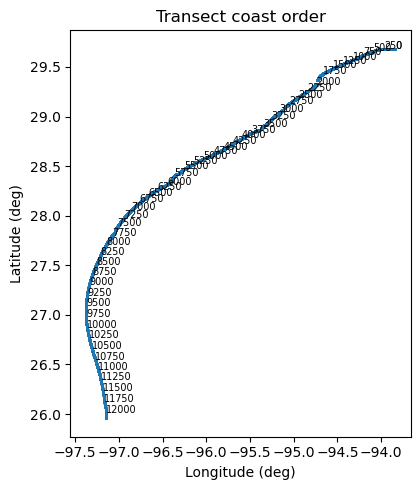

In [2]:
plot_coast_order_map( stats )

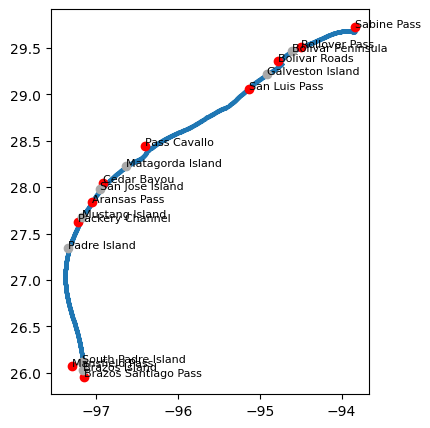

,name,lon,lat,transect_index,nearest_lon_mid,nearest_lat_mid,s_km,distance_deg
0,Brazos Santiago Pass,-97.15,25.96,12118,-97.145735,25.960281,0.342421,0.004274
1,Mansfield Pass,-97.30,26.07,11829,-97.159380,26.089112,14.936866,0.141913
2,Packery Channel,-97.22,27.63,8219,-97.198444,27.619859,192.215096,0.023822
3,Aransas Pass,-97.05,27.84,7636,-97.043900,27.839730,221.358457,0.006106
4,Cedar Bayou,-96.92,28.05,7114,-96.893568,28.022422,246.858596,0.038200
5,Pass Cavallo,-96.40,28.45,5747,-96.360495,28.402257,314.975328,0.061968
6,San Luis Pass,-95.13,29.06,2931,-95.132272,29.063210,457.414496,0.003933
7,Bolivar Roads,-94.78,29.36,1955,-94.730100,29.367503,511.489117,0.050461
8,Rollover Pass,-94.50,29.51,1384,-94.498912,29.506013,539.492720,0.004133
9,Sabine Pass,-93.84,29.73,0,-93.838448,29.678021,607.614734,0.052002


In [3]:
inlets = pd.DataFrame({
    "name": [
        "Brazos Santiago Pass",
        "Mansfield Pass",
        "Packery Channel",
        "Aransas Pass",
        "Cedar Bayou",
        "Pass Cavallo",
        "San Luis Pass",
        "Bolivar Roads",
        "Rollover Pass",
        "Sabine Pass"
    ],
    "lon": [
        -97.15,
        -97.30,
        -97.22,
        -97.05,
        -96.92,
        -96.40,
        -95.13,
        -94.78,
        -94.50,
        -93.84
    ],
    "lat": [
        25.96,
        26.07,
        27.63,
        27.84,
        28.05,
        28.45,
        29.06,
        29.36,
        29.51,
        29.73
    ]
})

islands = pd.DataFrame({
    "name": [
        "Brazos Island",
        "South Padre Island",
        "Padre Island",
        "Mustang Island",
        "San Jose Island",
        "Matagorda Island",
        "Galveston Island",
        "Bolivar Peninsula",
    ],
    "lon": [
        -97.15747,   # Brazos Island
        -97.16972,   # South Padre Island
        -97.34679,   # Padre Island (representative central point)
        -97.17693,   # Mustang Island
        -96.94694,   # San Jose Island
        -96.64026,   # Matagorda Island
        -94.90889,   # Galveston Island
        -94.60778,   # Bolivar Peninsula
    ],
    "lat": [
        26.03063,
        26.11194,
        27.34343,
        27.67531,
        27.97806,
        28.22723,
        29.22222,
        29.46444,
    ],
})


def assign_feature_alongshore_distance(stats, features):
    """
    Snap named coastal features (islands, inlets, etc.) to nearest transect midpoint
    and assign alongshore distance s_km.
    """
    if "s_km" not in stats.columns:
        raise ValueError("stats must include 's_km' (run with include_alongshore=True)")
    if "lon_mid" not in stats.columns or "lat_mid" not in stats.columns:
        raise ValueError("stats must include 'lon_mid' and 'lat_mid'")

    coords = np.vstack([stats["lon_mid"], stats["lat_mid"]]).T
    tree = cKDTree(coords)

    feat_coords = np.vstack([features["lon"], features["lat"]]).T
    dist, idx = tree.query(feat_coords)

    out = features.copy()
    out["transect_index"] = idx
    out["nearest_lon_mid"] = stats["lon_mid"].to_numpy()[idx]
    out["nearest_lat_mid"] = stats["lat_mid"].to_numpy()[idx]
    out["s_km"] = stats["s_km"].to_numpy()[idx]
    out["distance_deg"] = dist
    return out


inlets_s  = assign_feature_alongshore_distance(stats, inlets)
islands_s = assign_feature_alongshore_distance(stats, islands)

# Plot the inlets and islands
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(stats["lon_mid"], stats["lat_mid"], s=2)
ax.scatter(inlets["lon"], inlets["lat"], color="red")
ax.scatter(islands["lon"], islands["lat"], color="darkgray")

for _, row in inlets.iterrows():
    ax.text(row["lon"], row["lat"], row["name"], fontsize=8)
for _, row in islands_s.iterrows():
    ax.text(row["lon"], row["lat"], row["name"], fontsize=8)

ax.set_aspect(1 / np.cos(np.deg2rad(stats["lat_mid"].mean())))
plt.show()

inlets_s

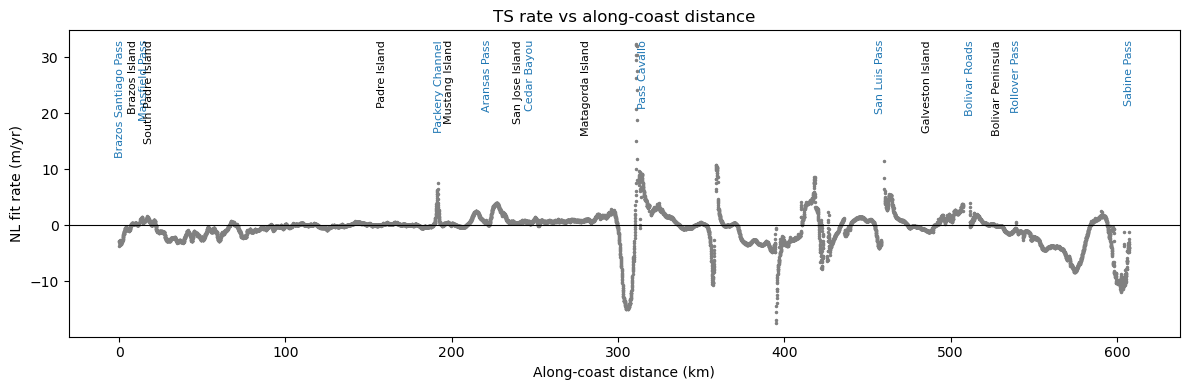

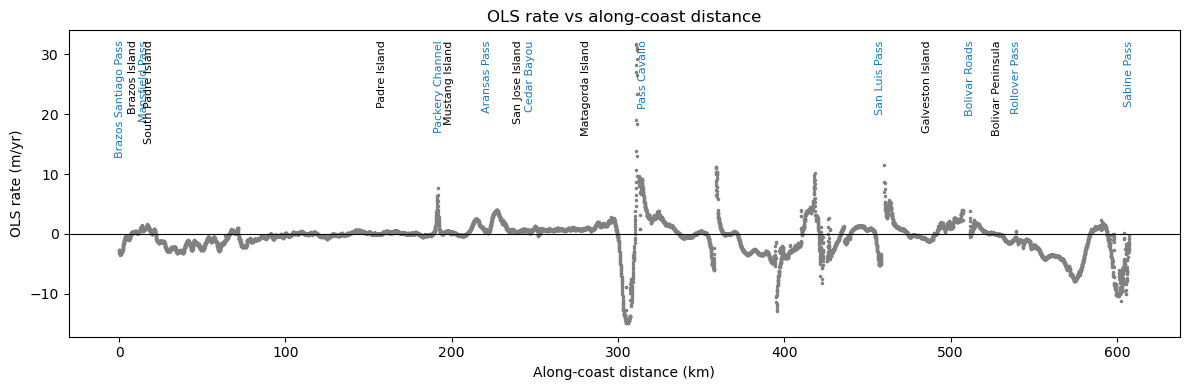

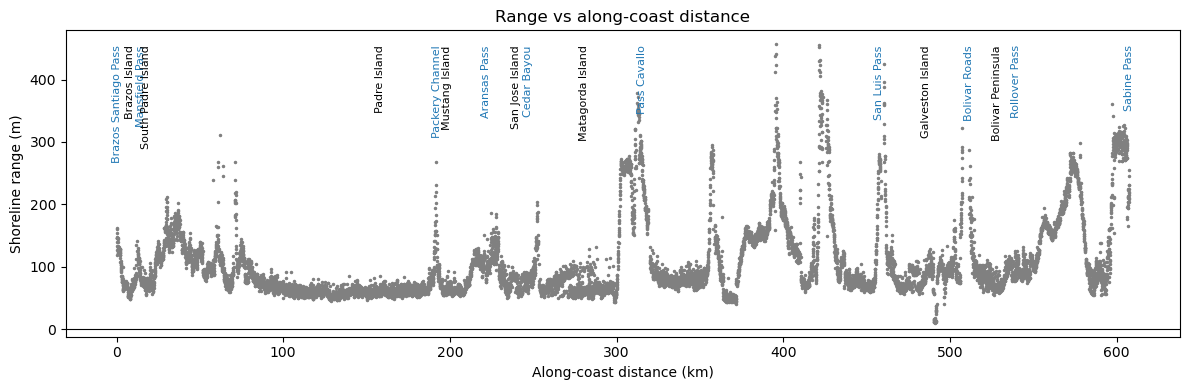

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Range vs along-coast distance'}, xlabel='Along-coast distance (km)', ylabel='Shoreline range (m)'>)

In [26]:
def plot_alongshore(df_stats, var, ylabel, title, inlets_s, islands_s):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(df_stats["s_km"], df_stats[var], ".", ms=3, color='gray')

    for _, row in inlets_s.iterrows():
        # ax.axvline(row["s_km"], color="k", lw=0.5)
        ax.text(row["s_km"], 0.95*ax.get_ylim()[1],
                row["name"], color = 'tab:blue',
                rotation=90, va="top", ha='center', fontsize=8)

    for _, row in islands_s.iterrows():
        # ax.axvline(row["s_km"], color="k", lw=0.5)
        ax.text(row["s_km"], 0.95*ax.get_ylim()[1],
                row["name"],
                rotation=90, va="top", ha='center', fontsize=8)

    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("Along-coast distance (km)")
    ax.set_ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax

fig, ax = plot_alongshore(stats, "rate_ts", ylabel="NL fit rate (m/yr)", title="TS rate vs along-coast distance", inlets_s=inlets_s, islands_s=islands_s)
fig.savefig('nl_fit_along-coasts.png', dpi=200)
fig, ax = plot_alongshore(stats, "rate_ols", ylabel="OLS rate (m/yr)", title="OLS rate vs along-coast distance", inlets_s=inlets_s, islands_s=islands_s)
fig.savefig('ols_fit_along-coasts.png', dpi=200)

plot_alongshore(stats, "shoreline_range", ylabel="Shoreline range (m)", title="Range vs along-coast distance", inlets_s=inlets_s, islands_s=islands_s)

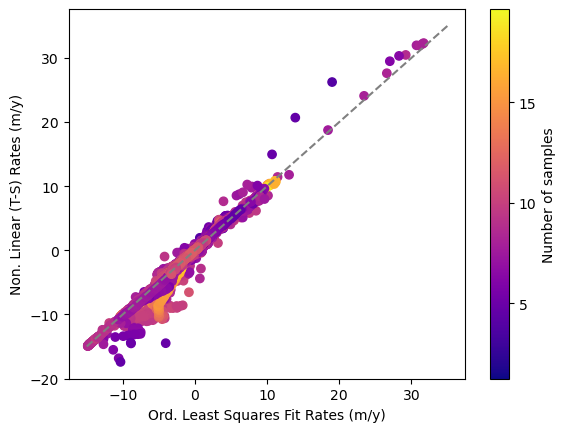

In [5]:
plt.plot([-15, 35],[-15, 35],'--',c='gray')
plt.scatter(stats['rate_ols'],stats['rate_ts'],c=stats['n_per_year'], cmap='plasma')
plt.xlabel('Ord. Least Squares Fit Rates (m/y)')
plt.ylabel('Non. Linear (T-S) Rates (m/y)')
ticks = np.arange(0, 25, 5)
plt.colorbar(label='Number of samples', ticks=ticks)
plt.savefig('regression_comparison.png', dpi=200)

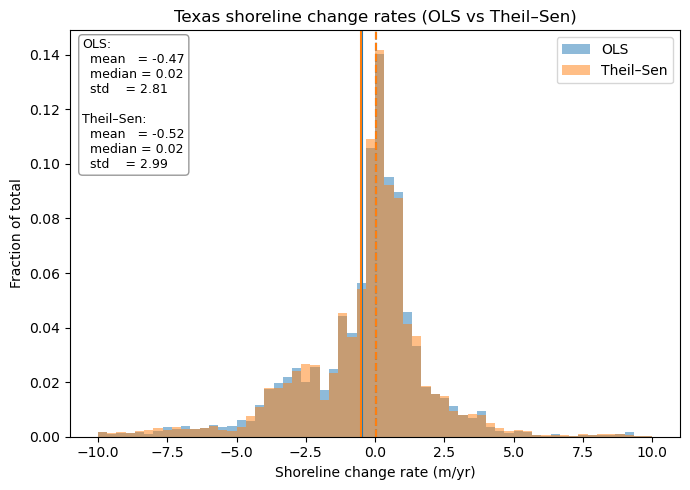

In [15]:
def plot_rate_histogram(
    stats,
    ols_col="rate_ols",
    ts_col="rate_ts",
    bins=50,
    range=None,
    alpha=0.5,
    colors=("tab:blue", "tab:orange"),
    labels=("OLS", "Theil–Sen"),
    xlabel="Shoreline change rate (m/yr)",
    ylabel="Fraction of total",
    title="Histogram of shoreline change rates",
    figsize=(7, 5),
    show_mean=True,
    show_median=True,
    show_stats_text=True,
    text_loc=(0.02, 0.98),
    ax=None,
):
    """
    Plot histograms of OLS and Theil–Sen rates on the same axis, with y-axis
    expressed as fraction of total and optional summary statistics text.

    Parameters
    ----------
    stats : DataFrame
        Must contain columns for OLS and TS rates.
    bins : int or array-like
        Histogram bins.
    range : tuple or None
        (min, max) for histogram.
    alpha : float
        Transparency for histogram fills.
    show_mean : bool
        Plot vertical solid lines for means.
    show_median : bool
        Plot vertical dashed lines for medians.
    show_stats_text : bool
        Add text box with mean, median, std for each series.
    text_loc : tuple
        Axes coordinates for upper-left corner of text box.
    """

    # Extract and clean
    ols = stats[ols_col].to_numpy(dtype=float)
    ts = stats[ts_col].to_numpy(dtype=float)

    ols = ols[np.isfinite(ols)]
    ts = ts[np.isfinite(ts)]

    # Create axis
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # Weights so histogram sums to 1
    w_ols = np.ones_like(ols) / len(ols) if len(ols) > 0 else None
    w_ts = np.ones_like(ts) / len(ts) if len(ts) > 0 else None

    # Plot histograms
    if len(ols) > 0:
        ax.hist(
            ols,
            bins=bins,
            range=range,
            weights=w_ols,
            alpha=alpha,
            color=colors[0],
            label=labels[0],
            edgecolor="none",
        )

    if len(ts) > 0:
        ax.hist(
            ts,
            bins=bins,
            range=range,
            weights=w_ts,
            alpha=alpha,
            color=colors[1],
            label=labels[1],
            edgecolor="none",
        )

    # Summary statistics
    ols_mean = np.nanmean(ols) if len(ols) > 0 else np.nan
    ols_median = np.nanmedian(ols) if len(ols) > 0 else np.nan
    ols_std = np.nanstd(ols, ddof=1) if len(ols) > 1 else np.nan

    ts_mean = np.nanmean(ts) if len(ts) > 0 else np.nan
    ts_median = np.nanmedian(ts) if len(ts) > 0 else np.nan
    ts_std = np.nanstd(ts, ddof=1) if len(ts) > 1 else np.nan

    # Vertical lines
    if show_mean and np.isfinite(ols_mean):
        ax.axvline(ols_mean, color=colors[0], linestyle="-", lw=1.5)
    if show_mean and np.isfinite(ts_mean):
        ax.axvline(ts_mean, color=colors[1], linestyle="-", lw=1.5)

    if show_median and np.isfinite(ols_median):
        ax.axvline(ols_median, color=colors[0], linestyle="--", lw=1.5)
    if show_median and np.isfinite(ts_median):
        ax.axvline(ts_median, color=colors[1], linestyle="--", lw=1.5)

    # Labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

    # Text box in upper left
    if show_stats_text:
        text = (
            f"{labels[0]}:\n"
            f"  mean   = {ols_mean:.2f}\n"
            f"  median = {ols_median:.2f}\n"
            f"  std    = {ols_std:.2f}\n\n"
            f"{labels[1]}:\n"
            f"  mean   = {ts_mean:.2f}\n"
            f"  median = {ts_median:.2f}\n"
            f"  std    = {ts_std:.2f}"
        )

        ax.text(
            text_loc[0], text_loc[1], text,
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="0.5")
        )

    plt.tight_layout()
    return fig, ax


(fig, ax) = plot_rate_histogram(
    stats,
    bins=60,
    range=(-10, 10),
    title="Texas shoreline change rates (OLS vs Theil–Sen)"
)
fig.savefig('ols-ts_histograms.png', dpi = 200)

In [16]:
stats

,ID,transectStart_X,transectStart_Y,transectEnd_X,transectEnd_Y,lon_mid,lat_mid,x_proj,y_proj,ds_m,...,SCE,NSM,EPR,LRR,rate_ols,intercept_ols,r2_ols,rmse_ols,rate_ts,intercept_ts
0,usa_TX_0001_0001,-93.838730,29.679420,-93.838165,29.676622,-93.838448,29.678021,2.095078e+06,7.300796e+06,NaN,...,203.671780,-96.414158,-2.509730,-2.545009,-2.545009,5189.980019,0.295034,39.282207,-3.303097,6701.815382
1,usa_TX_0001_0002,-93.839165,29.679419,-93.838630,29.676554,-93.838898,29.677986,2.095035e+06,7.300789e+06,43.651474,...,214.891027,-102.693728,-2.671668,-2.887272,-2.887272,5892.246835,0.309627,44.974880,-4.413831,8953.957052
2,usa_TX_0001_0003,-93.839580,29.679197,-93.839134,29.676485,-93.839357,29.677841,2.094991e+06,7.300771e+06,47.249041,...,254.517201,-48.405316,-1.262184,-2.418517,-2.418517,4945.317276,0.172504,52.500447,-4.034027,8179.082684
3,usa_TX_0001_0004,-93.840030,29.679037,-93.839660,29.676426,-93.839845,29.677732,2.094945e+06,7.300756e+06,48.697353,...,220.653845,-49.452837,-1.289498,-1.851680,-1.851680,3802.023779,0.092501,55.882580,-3.373768,6843.391996
4,usa_TX_0001_0005,-93.840515,29.679100,-93.840210,29.676373,-93.840362,29.677737,2.094895e+06,7.300754e+06,50.008749,...,231.403821,-40.402806,-1.053516,-2.084879,-2.084879,4277.200683,0.115680,57.038367,-3.934131,7978.637064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12121,usa_TX_0033_0242,-97.147250,25.959024,-97.144135,25.958958,-97.145692,25.958991,1.786409e+06,6.875716e+06,47.172955,...,127.128423,-83.732554,-2.300146,-2.633744,-2.633744,5344.502348,0.680116,15.695921,-2.677249,5430.912696
12122,usa_TX_0033_0243,-97.147290,25.958645,-97.144150,25.958508,-97.145720,25.958576,1.786407e+06,6.875670e+06,45.912468,...,146.044248,-135.834390,-3.648186,-2.740902,-2.740902,5561.873146,0.689347,16.489992,-2.812745,5706.251990
12123,usa_TX_0033_0244,-97.147310,25.958282,-97.144180,25.958065,-97.145745,25.958174,1.786406e+06,6.875625e+06,44.628493,...,146.606496,-146.504643,-3.925527,-2.608873,-2.608873,5296.987291,0.636855,17.679250,-2.793735,5668.803136
12124,usa_TX_0033_0245,-97.147415,25.957880,-97.144230,25.957617,-97.145822,25.957749,1.786399e+06,6.875578e+06,47.629611,...,118.750610,-92.199123,-2.503539,-2.694061,-2.694061,5473.003812,0.558398,21.472319,-3.044321,6178.088848


In [17]:

def make_time_bins(dt, time_freq="YS"):
    """
    Create time bins for heatmaps.

    Supported values include:
    - 'YS', 'AS', 'Y'      : annual bins starting Jan 1
    - 'season'             : meteorological seasons (DJF, MAM, JJA, SON)
    - 'QS', 'Q'            : quarterly bins starting Jan/Apr/Jul/Oct
    - 'MS', 'M'            : monthly bins
    - other pandas floor-compatible offsets like '30D'

    For 'season', bins are labeled by their start date using Q-DEC convention:
    DJF -> Dec 1 of prior year, MAM -> Mar 1, JJA -> Jun 1, SON -> Sep 1.
    """
    dt = pd.to_datetime(dt)
    tf = str(time_freq).lower()

    if tf in ["ys", "as", "ys-jan", "as-jan", "y"]:
        return pd.to_datetime(dt.dt.year.astype(str) + "-01-01")

    elif tf == "season":
        return dt.dt.to_period("Q-DEC").dt.to_timestamp()

    elif tf in ["qs", "q"]:
        qmonth = 3 * ((dt.dt.month - 1) // 3) + 1
        return pd.to_datetime(
            dt.dt.year.astype(str)
            + "-"
            + qmonth.astype(str).str.zfill(2)
            + "-01"
        )

    elif tf in ["ms", "m"]:
        return pd.to_datetime(
            dt.dt.year.astype(str)
            + "-"
            + dt.dt.month.astype(str).str.zfill(2)
            + "-01"
        )

    else:
        return dt.dt.floor(time_freq)

In [18]:
def plot_heatmap_swapped(
    df,
    stats,
    value="count",
    time_freq="YS",
    id_col="ID",
    time_col="datetime",
    s_col="s_km",
    figsize=(12, 7),
    cmap="viridis",
    cbar_label=None,
    vmin=None,
    vmax=None,
    title=None,
    nan_color="0.3",
    alpha=0.9
):
    """
    Heatmap with:
        x-axis = along-coast distance (km)
        y-axis = time (increasing downward)

    Same interface as plot_heatmap().
    """

    # --- time binning ---
    dfx = df.copy()
    dfx["time_bin"] = make_time_bins(dfx[time_col], time_freq=time_freq)

    # --- aggregation ---
    if value == "count":
        agg = (
            dfx.groupby([id_col, "time_bin"])
               .size()
               .rename("val")
               .reset_index()
        )
        cbar_label = "Samples per year"
    else:
        if value not in dfx.columns:
            raise ValueError(f"Column '{value}' not found in dataframe")
        agg = (
            dfx.groupby([id_col, "time_bin"])[value]
               .mean()
               .rename("val")
               .reset_index()
        )
        if cbar_label == None:
            cbar_label = value

    # --- merge alongshore distance ---
    tmp = agg.merge(stats[[id_col, s_col]], on=id_col, how="left")

    # --- pivot (NOTE: swapped axes) ---
    mat = tmp.pivot(index="time_bin", columns=s_col, values="val").sort_index()

    # --- colormap with NaN handling ---
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color=nan_color)

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    pcm = ax.pcolormesh(
        mat.columns.values,                      # x = alongshore
        mat.index.to_pydatetime(),               # y = time
        mat.values,
        shading="auto",
        cmap=cmap_obj,
        vmin=vmin,
        vmax=vmax,
        alpha=alpha
    )

    # invert y-axis so time increases downward
    ax.invert_yaxis()

    # colorbar
    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.set_label(cbar_label)

    # labels
    ax.set_xlabel("Along-coast distance (km)")
    ax.set_ylabel("Time")
    ax.set_title(title or f"{value} vs along-coast distance and time")

    plt.tight_layout()
    return fig, ax, mat

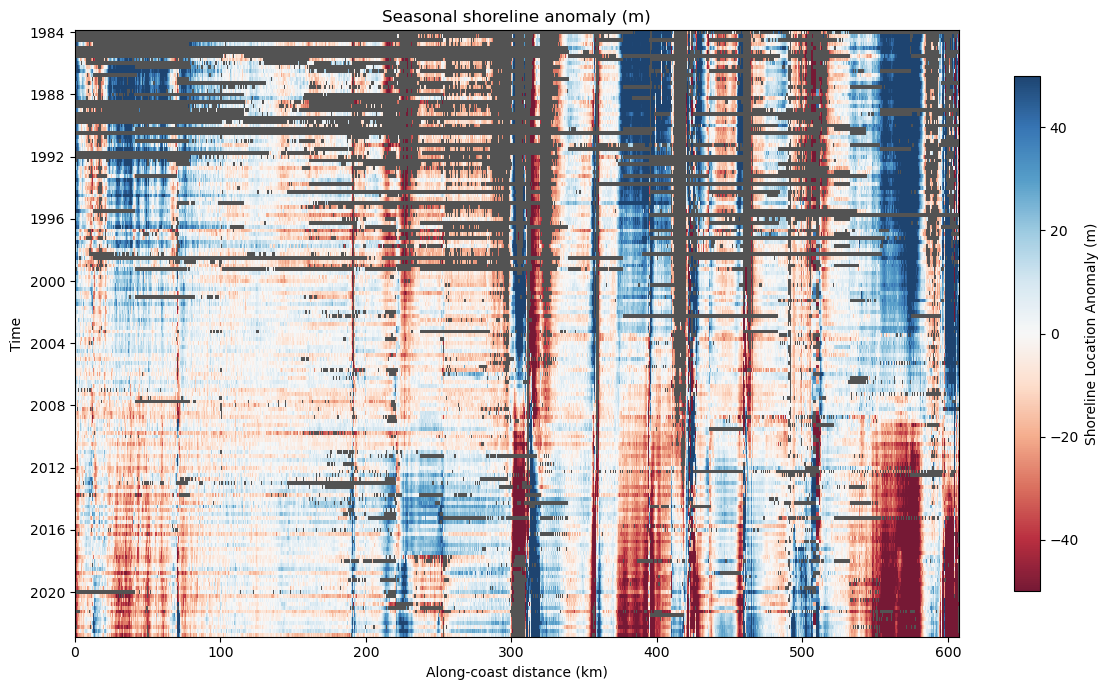

In [19]:
df["distance_anom"] = df.groupby("ID")["distance"].transform(lambda x: x - x.mean())
(fig,_,_) = plot_heatmap_swapped(
    df, stats,
    value="distance_anom",
    time_freq="season",
    cmap="RdBu",
    vmin=-50, vmax=50,
    nan_color="0.25",
    cbar_label = 'Shoreline Location Anomaly (m)',
    title="Seasonal shoreline anomaly (m)"
)
fig.savefig('seasonal_anomoly_s.png', dpi=200)

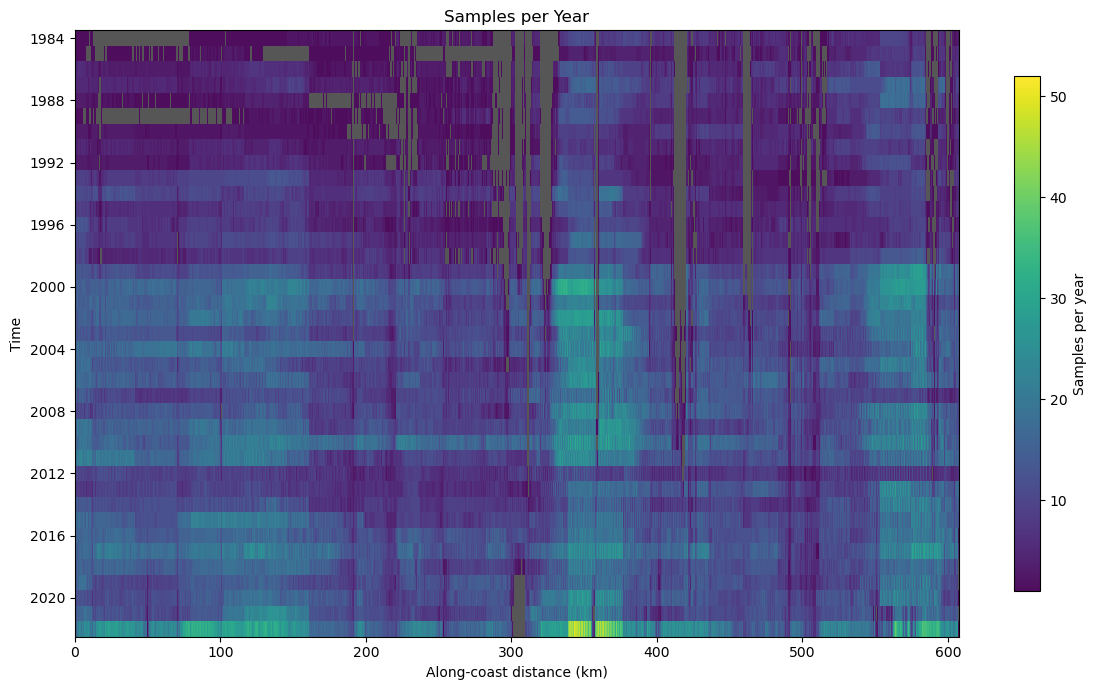

In [20]:
(fig,_,_) = plot_heatmap_swapped(df, stats,
             value="count",
             time_freq="YS",
             cmap='viridis',
             cbar_label='Samples per Year',
             title="Samples per Year", alpha=.95)
fig.savefig('sample_frequency.png', dpi=200)

In [24]:
# -----------------------------------------------------------------------------
# 1. Read IBTrACS North Atlantic CSV
# -----------------------------------------------------------------------------

def read_ibtracs_na(
    csvfile="ibtracs.NA.list.v04r01.csv",
    start_date="1984-01-01",
    end_date="2022-12-31",
):
    """
    Read IBTrACS North Atlantic CSV and return a cleaned dataframe.

    Notes
    -----
    IBTrACS CSV usually has a second row of units, so skiprows=[1].
    """
    df = pd.read_csv(csvfile, skiprows=[1], low_memory=False)

    # Parse time
    if "ISO_TIME" not in df.columns:
        raise ValueError("Expected column 'ISO_TIME' not found in IBTrACS file.")

    df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce", utc=True)

    # Core numeric columns
    for col in ["LAT", "LON", "USA_WIND", "WMO_WIND"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Storm identifier
    if "SID" not in df.columns:
        raise ValueError("Expected column 'SID' not found in IBTrACS file.")

    # Storm name
    if "NAME" in df.columns:
        df["storm_name"] = (
            df["NAME"]
            .fillna("")
            .astype(str)
            .str.strip()
            .replace({"": "UNNAMED", "NOT_NAMED": "UNNAMED"})
        )
    else:
        df["storm_name"] = "UNNAMED"

    # Choose a wind column
    if "USA_WIND" in df.columns and df["USA_WIND"].notna().any():
        wind_col = "USA_WIND"
    elif "WMO_WIND" in df.columns and df["WMO_WIND"].notna().any():
        wind_col = "WMO_WIND"
    else:
        wind_col = None

    df["wind_kt"] = df[wind_col] if wind_col is not None else np.nan

    # Keep only rows with valid time/lat/lon
    df = df.dropna(subset=["ISO_TIME", "LAT", "LON"]).copy()

    # Filter to shoreline-data period
    t0 = pd.Timestamp(start_date, tz="UTC")
    t1 = pd.Timestamp(end_date, tz="UTC")
    df = df[(df["ISO_TIME"] >= t0) & (df["ISO_TIME"] <= t1)].copy()

    # Sort
    df = df.sort_values(["SID", "ISO_TIME"]).reset_index(drop=True)

    return df


# -----------------------------------------------------------------------------
# 2. Build coastline polyline from transect stats
# -----------------------------------------------------------------------------

def build_tx_coastline_from_stats(
    stats,
    lon_col="lon_mid",
    lat_col="lat_mid",
    proj_crs="EPSG:3083",
):
    """
    Build projected coastline polyline from transect midpoints.

    Expects stats to already be coast-ordered, e.g. by s_km or coast_order.
    """
    if "s_km" in stats.columns:
        ss = stats.sort_values("s_km").copy()
    elif "coast_order" in stats.columns:
        ss = stats.sort_values("coast_order").copy()
    else:
        raise ValueError("stats must contain 's_km' or 'coast_order'.")

    xf = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
    xb, yb = xf.transform(ss[lon_col].to_numpy(), ss[lat_col].to_numpy())

    coastline = LineString(np.column_stack([xb, yb]))
    return coastline, ss


# -----------------------------------------------------------------------------
# 3. Helpers for landfall interpolation
# -----------------------------------------------------------------------------

def _pick_intersection_point(intersection, seg_start_point):
    """
    Reduce an intersection geometry to a single Point.
    """
    if intersection.is_empty:
        return None

    if isinstance(intersection, Point):
        return intersection

    if isinstance(intersection, MultiPoint):
        pts = list(intersection.geoms)
        pts = sorted(pts, key=lambda p: p.distance(seg_start_point))
        return pts[0]

    if isinstance(intersection, GeometryCollection):
        pts = [g for g in intersection.geoms if isinstance(g, Point)]
        if len(pts) == 0:
            return None
        pts = sorted(pts, key=lambda p: p.distance(seg_start_point))
        return pts[0]

    # If segment overlaps coastline, use midpoint of overlap bounds
    try:
        x0, y0, x1, y1 = intersection.bounds
        return Point(0.5 * (x0 + x1), 0.5 * (y0 + y1))
    except Exception:
        return None


def _interp_scalar(a, b, frac):
    if np.isfinite(a) and np.isfinite(b):
        return a + frac * (b - a)
    elif np.isfinite(a):
        return a
    elif np.isfinite(b):
        return b
    else:
        return np.nan


# -----------------------------------------------------------------------------
# 4. Find first coastline crossing / landfall for each storm
# -----------------------------------------------------------------------------

def find_ibtracs_landfalls(
    ib,
    stats,
    proj_crs="EPSG:3083",
    lon_col="lon_mid",
    lat_col="lat_mid",
):
    """
    Identify storms whose tracks cross the coastline polyline defined by transects.

    Returns one row per storm, using the first crossing encountered.
    """
    coastline, ss = build_tx_coastline_from_stats(
        stats, lon_col=lon_col, lat_col=lat_col, proj_crs=proj_crs
    )

    # transformers
    fwd = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
    inv = Transformer.from_crs(proj_crs, "EPSG:4326", always_xy=True)

    events = []

    for sid, g in ib.groupby("SID"):
        g = g.sort_values("ISO_TIME").reset_index(drop=True)
        if len(g) < 2:
            continue

        # project storm points
        xtrk, ytrk = fwd.transform(g["LON"].to_numpy(), g["LAT"].to_numpy())
        storm_max_wind = np.nanmax(g["wind_kt"].to_numpy()) if g["wind_kt"].notna().any() else np.nan
        storm_name = g["storm_name"].iloc[0]

        found = False

        for i in range(len(g) - 1):
            p1 = Point(xtrk[i], ytrk[i])
            p2 = Point(xtrk[i + 1], ytrk[i + 1])
            seg = LineString([p1, p2])

            # "crosses" can miss edge cases; "intersects" is safer here
            if not seg.intersects(coastline):
                continue

            inter = seg.intersection(coastline)
            p_int = _pick_intersection_point(inter, p1)
            if p_int is None:
                continue

            seg_len = seg.length
            if seg_len == 0:
                frac = 0.0
            else:
                frac = p1.distance(p_int) / seg_len
                frac = np.clip(frac, 0.0, 1.0)

            # Interpolate crossing time
            t1 = g.loc[i, "ISO_TIME"]
            t2 = g.loc[i + 1, "ISO_TIME"]
            dt = t2 - t1
            t_cross = t1 + frac * dt

            # Interpolate wind at crossing
            w1 = g.loc[i, "wind_kt"]
            w2 = g.loc[i + 1, "wind_kt"]
            wind_landfall = _interp_scalar(w1, w2, frac)

            # Crossing lat/lon
            lon_cross, lat_cross = inv.transform(p_int.x, p_int.y)

            # Along-coast coordinate
            s_m = coastline.project(p_int)
            s_km = s_m / 1000.0

            events.append({
                "SID": sid,
                "storm_name": storm_name,
                "landfall_time": t_cross,
                "landfall_date": pd.Timestamp(t_cross).date(),
                "landfall_lat": lat_cross,
                "landfall_lon": lon_cross,
                "wind_landfall_kt": wind_landfall,
                "storm_max_wind_kt": storm_max_wind,
                "s_km": s_km,
            })

            found = True
            break

        if found:
            continue

    landfalls = pd.DataFrame(events)

    if len(landfalls) == 0:
        return landfalls

    landfalls = landfalls.sort_values("landfall_time").reset_index(drop=True)
    return landfalls


# -----------------------------------------------------------------------------
# 5. Annotate the swapped heatmap with landfalls
# -----------------------------------------------------------------------------

def annotate_landfalls_on_heatmap(
    ax,
    landfalls,
    x_col="s_km",
    y_col="landfall_time",
    label_col="storm_name",
    marker="*",
    ms=60,
    color="straw",
    text_rotation=0,
    fontsize=10,
    label_storms=True,
):
    """
    Add storm landfall markers to a swapped heatmap:
        x = along-coast distance
        y = time (typically inverted)
    """
    if len(landfalls) == 0:
        return ax

    # ax.scatter(
    #     landfalls[x_col],
    #     pd.to_datetime(landfalls[y_col]),
    #     s=ms,
    #     marker=marker,
    #     c=color,
    #     edgecolors="white",
    #     linewidths=0.5,
    #     zorder=5,
    # )
    

    if label_storms:
        for _, row in landfalls.iterrows():
            ax.text(
                row[x_col],
                pd.to_datetime(row[y_col]),
                f" {row[label_col]}",
                fontsize=fontsize,
                rotation=text_rotation,
                va="bottom",
                ha="center",
                color=color,
                zorder=6,
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    facecolor="0.85",   # light gray
                    edgecolor="none",
                    alpha=0.8
                )
            )

    return ax

In [22]:
# storms
ib = read_ibtracs_na("ibtracs.NA.list.v04r01.csv",
                     start_date="1984-01-01",
                     end_date="2022-12-31")

landfalls = find_ibtracs_landfalls(ib, stats)

# filter for at least tropical storm force
landfalls = landfalls[landfalls["wind_landfall_kt"] >= 34]

print(landfalls[[
    "storm_name",
    "landfall_time",
    "landfall_lat",
    "landfall_lon",
    "wind_landfall_kt",
    "storm_max_wind_kt",
    "s_km",
]])

   storm_name                       landfall_time  landfall_lat  landfall_lon  \
0      BONNIE 1986-06-26 10:07:32.115830763+00:00     29.618842    -94.206261   
2     UNNAMED 1987-08-10 06:02:02.737479661+00:00     29.505683    -94.500000   
3     ALLISON 1989-06-26 13:14:17.436813966+00:00     28.723820    -95.700000   
4     CHANTAL 1989-08-01 12:35:27.189678131+00:00     29.559099    -94.359064   
5       JERRY 1989-10-16 00:18:55.258253398+00:00     29.163071    -95.000000   
6      ARLENE 1993-06-20 08:38:34.261846289+00:00     27.088113    -97.376169   
7        DEAN 1995-07-31 00:47:20.941368572+00:00     29.079004    -95.118225   
8     CHARLEY 1998-08-22 09:52:25.831625031+00:00     27.787389    -97.087373   
9     FRANCES 1998-09-11 05:24:32.043308174+00:00     28.101664    -96.801080   
10       BRET 1999-08-22 23:39:48.443955439+00:00     26.888819    -97.366316   
12    ALLISON 2001-06-05 21:14:37.280996041+00:00     28.932497    -95.300000   
14        FAY 2002-09-07 08:

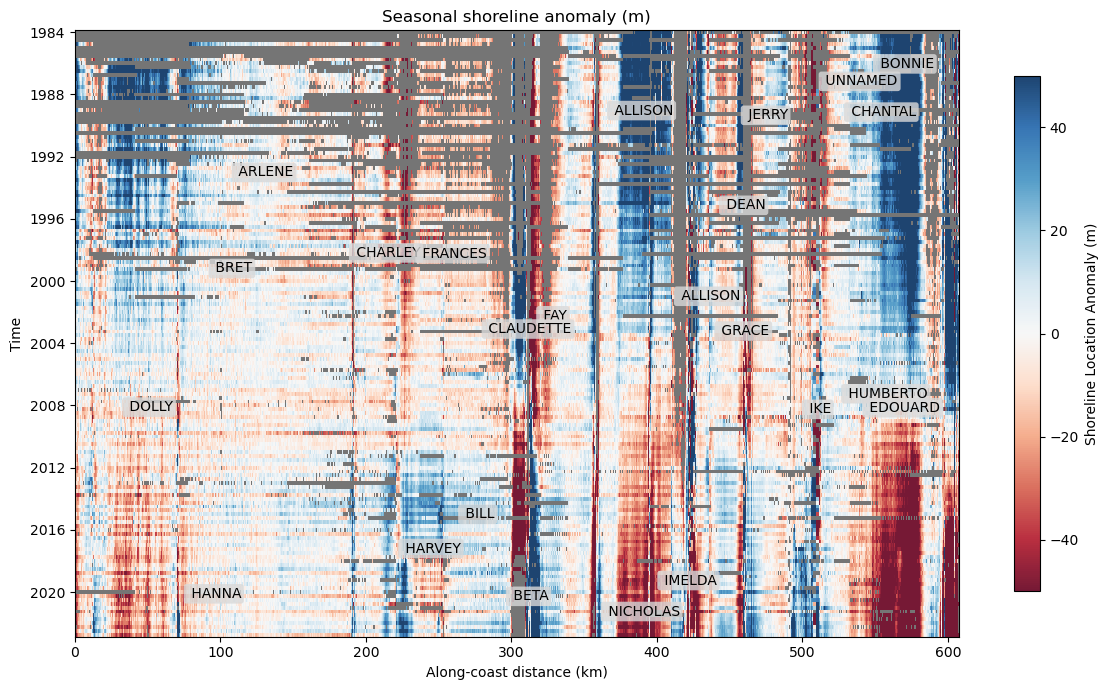

In [25]:
fig, ax, mat = plot_heatmap_swapped(
    df, stats,
    value="distance_anom",
    time_freq="season",
    cmap="RdBu",
    vmin=-50, vmax=50,
    nan_color="0.4",
    cbar_label='Shoreline Location Anomaly (m)',
    title="Seasonal shoreline anomaly (m)"
)
annotate_landfalls_on_heatmap(ax, landfalls, color='black', label_storms=True)

fig.savefig('seasonal_anomoly_s.png', dpi=200)